# Actividad: Clasificacion de stroke con Regresion Logistica y Naive Bayes

Este notebook documenta el flujo completo de la actividad y deja trazabilidad del cambio metodologico aplicado a la regresion logistica.

## 1. Objetivo y hoja de ruta

Objetivo: implementar y comparar modelos supervisados para clasificar la variable `stroke` a partir de variables continuas y categoricas.

Estructura del desarrollo:

1. Librerias y configuracion.
2. Carga del dataset.
3. Inspeccion inicial del conjunto de datos.
4. EDA de variables continuas.
5. EDA de variables categoricas.
6. Conclusiones del EDA.
7. Preprocesamiento y particion de datos.
8. Modelos base.
9. Diagnostico de la regresion logistica base.
10. Regresion logistica ajustada.
11. Comparacion final de modelos.
12. Conclusiones finales.

## 2. Librerias y configuracion

In [27]:
# Descomenta la siguiente linea si el entorno del notebook no tiene kagglehub.
# %pip install kagglehub

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
TARGET = "stroke"
ID_COLUMN = "id"

continuous_features = ["age", "avg_glucose_level", "bmi"]
categorical_features = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

BASE_DIR = Path.cwd().resolve()
PROJECT_DIR = BASE_DIR.parent if BASE_DIR.name == "notebooks" else BASE_DIR
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## 3. Carga del dataset

In [28]:
DATASET_SLUG = "fedesoriano/stroke-prediction-dataset"

# Ruta local opcional para reutilizar un CSV ya descargado.
LOCAL_DATA_PATH = None


def load_stroke_dataset(local_path: str | None = None) -> tuple[pd.DataFrame, Path]:
    """Carga el dataset desde una ruta local o desde Kaggle Hub."""
    if local_path:
        csv_path = Path(local_path).expanduser().resolve()
        if not csv_path.exists():
            raise FileNotFoundError(f"No se encontro el archivo: {csv_path}")
        return pd.read_csv(csv_path), csv_path

    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "kagglehub no esta instalado. Ejecuta `%pip install kagglehub` "
            "o define LOCAL_DATA_PATH con la ruta del CSV."
        ) from exc

    try:
        dataset_dir = Path(kagglehub.dataset_download(DATASET_SLUG))
    except Exception as exc:
        raise RuntimeError(
            "No se pudo descargar el dataset desde Kaggle. "
            "Revisa el acceso a Kaggle o usa una ruta local en LOCAL_DATA_PATH."
        ) from exc

    csv_files = sorted(dataset_dir.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontro ningun CSV dentro de {dataset_dir}")

    csv_path = csv_files[0]
    return pd.read_csv(csv_path), csv_path


df, data_path = load_stroke_dataset(LOCAL_DATA_PATH)

print(f"Archivo cargado: {data_path}")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
Archivo cargado: /kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv
Dimensiones del dataset: 5110 filas x 12 columnas


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 4. Inspeccion inicial del conjunto de datos

Criterios de trabajo usados en el notebook:

- `id` se excluye del modelado porque solo funciona como identificador unico.
- `hypertension` y `heart_disease` se tratan como variables categoricas binarias.
- La categoria `Unknown` de `smoking_status` se conserva como categoria valida, ya que representa informacion no disponible y no un valor nulo real.

In [29]:
def build_missing_summary(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Resume faltantes por columna en cantidad y porcentaje."""
    return (
        dataframe.isna().sum()
        .rename("missing_count")
        .to_frame()
        .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(dataframe))
        .sort_values("missing_pct", ascending=False)
    )


missing_summary = build_missing_summary(df)

print("Informacion general del dataset:\n")
df.info()

print(f"\nValores unicos en id: {df[ID_COLUMN].nunique()} de {len(df)} registros")
print(f"Registros duplicados: {df.duplicated().sum()}")
print(f"Proporcion de casos positivos (stroke = 1): {df[TARGET].mean():.2%}")

display(missing_summary)

Informacion general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Valores unicos en id: 5110 de 5110 registros
Registros duplicados: 0
Proporcion de casos positivos (stroke = 1): 4.87%


,missing_count,missing_pct
bmi,201,3.933464
id,0,0.000000
age,0,0.000000
gender,0,0.000000
hypertension,0,0.000000
heart_disease,0,0.000000
work_type,0,0.000000
ever_married,0,0.000000
Residence_type,0,0.000000
avg_glucose_level,0,0.000000


## 5. EDA de variables continuas

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60


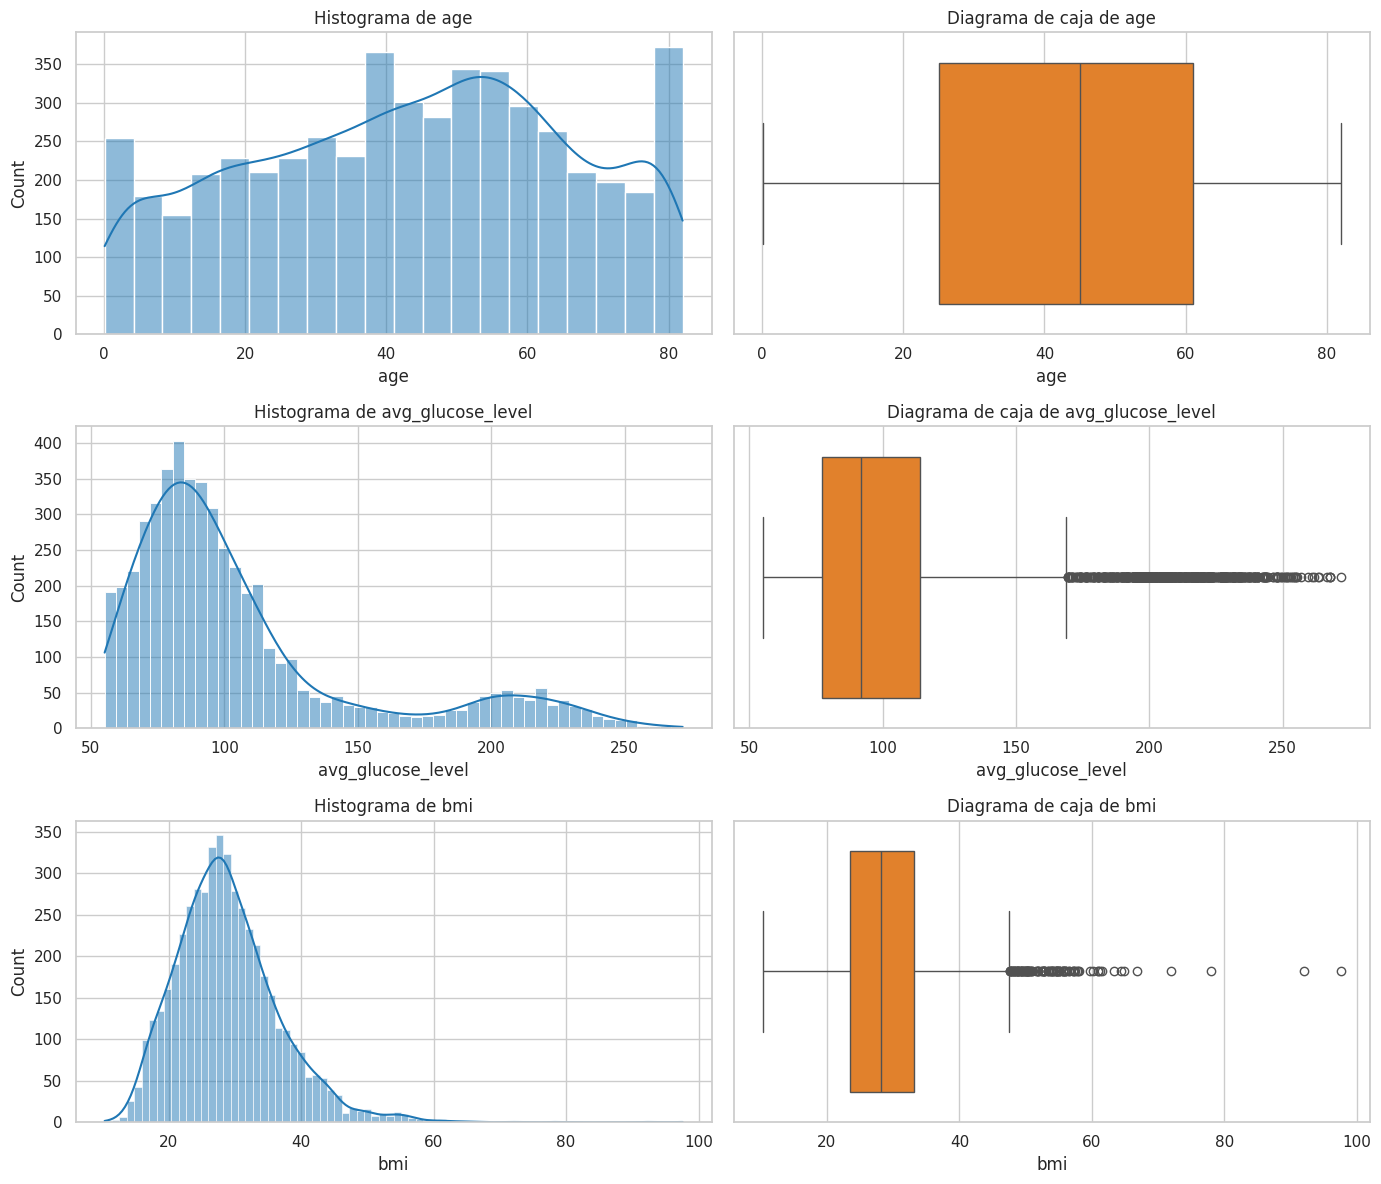

In [30]:
def plot_continuous_distributions(dataframe: pd.DataFrame, columns: list[str]) -> None:
    """Grafica histogramas y diagramas de caja para variables continuas."""
    fig, axes = plt.subplots(len(columns), 2, figsize=(14, 4 * len(columns)))

    for idx, column in enumerate(columns):
        sns.histplot(dataframe[column], kde=True, ax=axes[idx, 0], color="#1f77b4")
        axes[idx, 0].set_title(f"Histograma de {column}")
        axes[idx, 0].set_xlabel(column)

        sns.boxplot(x=dataframe[column], ax=axes[idx, 1], color="#ff7f0e")
        axes[idx, 1].set_title(f"Diagrama de caja de {column}")
        axes[idx, 1].set_xlabel(column)

    plt.tight_layout()
    plt.show()


display(df[continuous_features].describe().T)
plot_continuous_distributions(df, continuous_features)

## 6. EDA de variables categoricas

,unique_values,top_category,top_frequency
gender,3,Female,2994
hypertension,2,0,4612
heart_disease,2,0,4834
ever_married,2,Yes,3353
work_type,5,Private,2925
Residence_type,2,Urban,2596
smoking_status,4,never smoked,1892


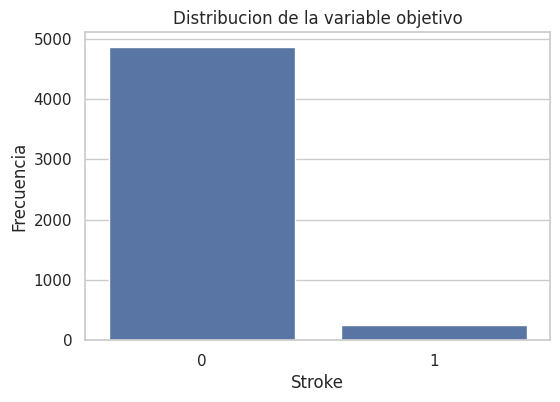

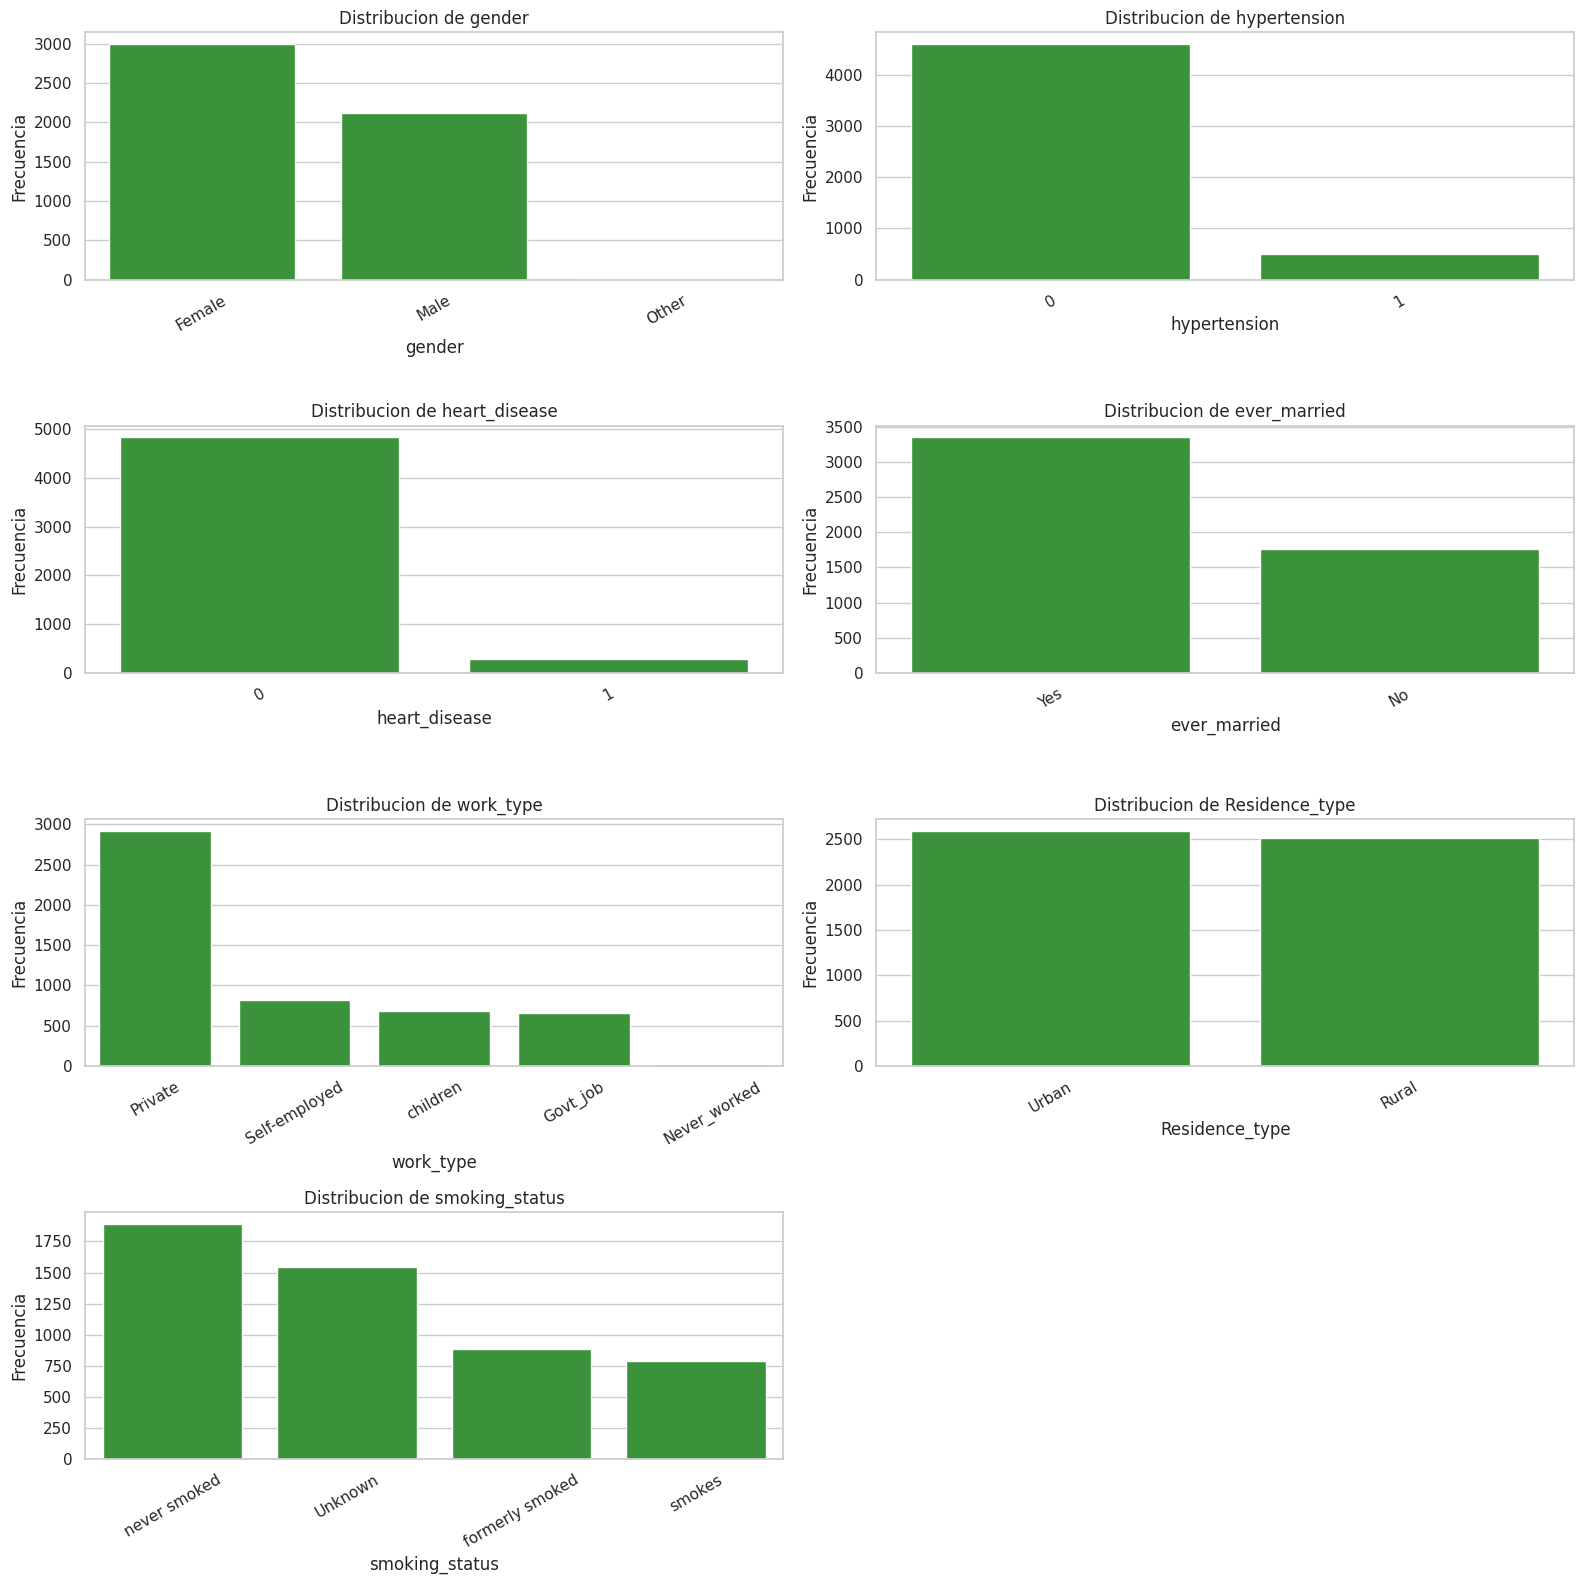

In [31]:
def summarize_categorical_variables(dataframe: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Resume categorias y frecuencias dominantes por variable."""
    return pd.DataFrame({
        "unique_values": dataframe[columns].nunique(),
        "top_category": dataframe[columns].mode().iloc[0],
        "top_frequency": [dataframe[col].value_counts(dropna=False).iloc[0] for col in columns],
    })


def plot_categorical_distributions(
    dataframe: pd.DataFrame,
    columns: list[str],
    n_cols: int = 2,
) -> None:
    """Grafica la distribucion de frecuencia de variables categoricas."""
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, column in zip(axes, columns):
        order = dataframe[column].value_counts(dropna=False).index
        sns.countplot(data=dataframe, x=column, order=order, ax=ax, color="#2ca02c")
        ax.set_title(f"Distribucion de {column}")
        ax.set_xlabel(column)
        ax.set_ylabel("Frecuencia")
        ax.tick_params(axis="x", rotation=30)

    for ax in axes[len(columns):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


display(summarize_categorical_variables(df, categorical_features))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, ax=ax)
ax.set_title("Distribucion de la variable objetivo")
ax.set_xlabel("Stroke")
ax.set_ylabel("Frecuencia")
plt.show()

plot_categorical_distributions(df, categorical_features)

## 7. Conclusiones del EDA

A partir del analisis exploratorio se obtienen los siguientes hallazgos clave antes de modelar:

1. El dataset contiene **5110 registros y 12 variables**, con estructura adecuada para clasificacion supervisada.
2. La columna `id` tiene **5110 valores unicos** y no hay registros duplicados, por lo que funciona solo como identificador.
3. Los valores faltantes se concentran unicamente en `bmi`, con **201 observaciones faltantes (3.93%)**, lo que justifica imputacion puntual.
4. La variable objetivo esta **fuertemente desbalanceada**: `stroke = 1` representa solo **4.87%** del total.
5. `avg_glucose_level` y `bmi` presentan asimetria positiva y valores atipicos, mientras que `age` muestra una dispersion amplia pero esperable.
6. En las variables categoricas predominan ciertas categorias, por ejemplo `Female`, `Private`, `Urban` y `never smoked`.
7. Estos resultados justifican imputacion, codificacion `OneHotEncoder`, estandarizacion de variables continuas, particion estratificada y una evaluacion que no dependa solo de `accuracy`.

## 8. Preprocesamiento y particion de datos

In [32]:
def export_dataframe(df: pd.DataFrame, output_path: Path) -> None:
    """Exporta un DataFrame a CSV preservando el indice."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path)


def save_current_figure(output_path: Path) -> None:
    """Guarda la figura actual en la ruta indicada."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, bbox_inches="tight", dpi=300)


def build_one_hot_encoder() -> OneHotEncoder:
    """Configura el codificador para variables categoricas."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(
    continuous_columns: list[str],
    categorical_columns: list[str],
) -> ColumnTransformer:
    """Construye el flujo de transformacion para variables mixtas."""
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, continuous_columns),
            ("cat", categorical_transformer, categorical_columns),
        ]
    )


def extract_positive_scores(pipeline: Pipeline, X_data: pd.DataFrame) -> np.ndarray | None:
    """Obtiene el score de la clase positiva desde el clasificador entrenado."""
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X_data)[:, 1]
    if hasattr(pipeline, "decision_function"):
        return pipeline.decision_function(X_data)
    return None


def compute_classification_metrics(
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    y_score: pd.Series | np.ndarray | None = None,
) -> dict[str, float | int | str]:
    """Calcula metricas de clasificacion y conteos de confusion."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "TP": int(tp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
    }

    if y_score is not None:
        y_score = np.asarray(y_score)
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_score)
        metrics["PR-AUC"] = average_precision_score(y_true, y_score)
    else:
        metrics["ROC-AUC"] = np.nan
        metrics["PR-AUC"] = np.nan

    return metrics


def split_training_for_threshold_tuning(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    validation_size: float = 0.2,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Separa entrenamiento interno y validacion para elegir umbral."""
    return train_test_split(
        X_train,
        y_train,
        test_size=validation_size,
        stratify=y_train,
        random_state=random_state,
    )


def apply_threshold(y_score: np.ndarray, threshold: float) -> np.ndarray:
    """Convierte probabilidades en clases usando un umbral dado."""
    return (np.asarray(y_score) >= threshold).astype(int)


def evaluate_thresholds(
    y_true: pd.Series | np.ndarray,
    y_score: pd.Series | np.ndarray,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    """Evalua un barrido de umbrales sobre validacion."""
    rows = []
    for threshold in thresholds:
        y_pred = apply_threshold(y_score, threshold)
        metrics = compute_classification_metrics(y_true, y_pred)
        rows.append({
            "threshold": threshold,
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "Specificity": metrics["Specificity"],
            "F1-score": metrics["F1-score"],
            "Balanced Accuracy": metrics["Balanced Accuracy"],
            "TP": metrics["TP"],
            "TN": metrics["TN"],
            "FP": metrics["FP"],
            "FN": metrics["FN"],
        })
    return pd.DataFrame(rows)


def select_best_threshold(threshold_results: pd.DataFrame) -> float:
    """Selecciona el mejor umbral con el criterio definido."""
    ranking = threshold_results.assign(distance_to_050=(threshold_results["threshold"] - 0.50).abs())
    ranking = ranking.sort_values(
        by=["F1-score", "Recall", "Specificity", "distance_to_050"],
        ascending=[False, False, False, True],
    )
    return float(ranking.iloc[0]["threshold"])


def plot_threshold_tradeoff(
    threshold_results: pd.DataFrame,
    selected_threshold: float,
) -> None:
    """Visualiza el compromiso entre metricas segun el umbral."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(threshold_results["threshold"], threshold_results["Precision"], marker="o", label="Precision")
    ax.plot(threshold_results["threshold"], threshold_results["Recall"], marker="o", label="Recall")
    ax.plot(threshold_results["threshold"], threshold_results["F1-score"], marker="o", label="F1-score")
    ax.axvline(selected_threshold, color="red", linestyle="--", label=f"Umbral optimo = {selected_threshold:.2f}")
    ax.set_title("Barrido de umbral para la regresion logistica balanceada")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Valor de la metrica")
    ax.legend()
    plt.tight_layout()


def build_classification_report(y_true: pd.Series, y_pred: np.ndarray) -> pd.DataFrame:
    """Construye el reporte de clasificacion en formato tabular."""
    return pd.DataFrame(
        classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    ).T


def evaluate_classifier(
    model_name: str,
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
) -> tuple[dict[str, float | int | str], pd.DataFrame, np.ndarray, np.ndarray | None, Pipeline]:
    """Entrena un clasificador y devuelve metricas, reporte, predicciones y pipeline."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_score = extract_positive_scores(pipeline, X_test)
    metrics_row = compute_classification_metrics(y_test, y_pred, y_score)
    metrics_row["Modelo"] = model_name
    report = build_classification_report(y_test, y_pred)
    return metrics_row, report, y_pred, y_score, pipeline


def plot_confusion_matrices(
    y_true: pd.Series,
    predictions_dict: dict[str, np.ndarray],
    n_cols: int = 2,
) -> None:
    """Visualiza matrices de confusion para varios modelos."""
    n_rows = int(np.ceil(len(predictions_dict) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (model_name, y_pred) in zip(axes, predictions_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(f"Matriz de confusion - {model_name}")
        ax.set_xlabel("Prediccion")
        ax.set_ylabel("Valor real")
        ax.set_xticklabels(["No stroke", "Stroke"])
        ax.set_yticklabels(["No stroke", "Stroke"], rotation=0)

    for ax in axes[len(predictions_dict):]:
        ax.axis("off")

    plt.tight_layout()


X = df.drop(columns=[TARGET, ID_COLUMN])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

preprocessor = build_preprocessor(continuous_features, categorical_features)
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")
print(f"Numero de variables despues del preprocesamiento: {len(feature_names)}")
display(pd.Series(feature_names, name="processed_feature").to_frame().head(15))

Conjunto de entrenamiento: (4088, 10)
Conjunto de prueba: (1022, 10)
Numero de variables despues del preprocesamiento: 23


,processed_feature
0,num__age
1,num__avg_glucose_level
2,num__bmi
3,cat__gender_Female
4,cat__gender_Male
5,cat__gender_Other
6,cat__hypertension_0
7,cat__hypertension_1
8,cat__heart_disease_0
9,cat__heart_disease_1


## 9. Modelos base

Esta primera evaluacion conserva el procedimiento original de la actividad para dejar trazabilidad del experimento inicial.

,Accuracy,Precision,Recall,F1-score
Modelo,,,,
GaussianNB,0.323,0.066,0.98,0.124
Regresion logistica base,0.952,1.000,0.02,0.039



Reporte de clasificacion - Regresion logistica base


,precision,recall,f1-score,support
0,0.952,1.000,0.975,972.000
1,1.000,0.020,0.039,50.000
accuracy,0.952,0.952,0.952,0.952
macro avg,0.976,0.510,0.507,1022.000
weighted avg,0.954,0.952,0.930,1022.000



Reporte de clasificacion - GaussianNB


,precision,recall,f1-score,support
0,0.996,0.289,0.448,972.000
1,0.066,0.980,0.124,50.000
accuracy,0.323,0.323,0.323,0.323
macro avg,0.531,0.635,0.286,1022.000
weighted avg,0.951,0.323,0.432,1022.000


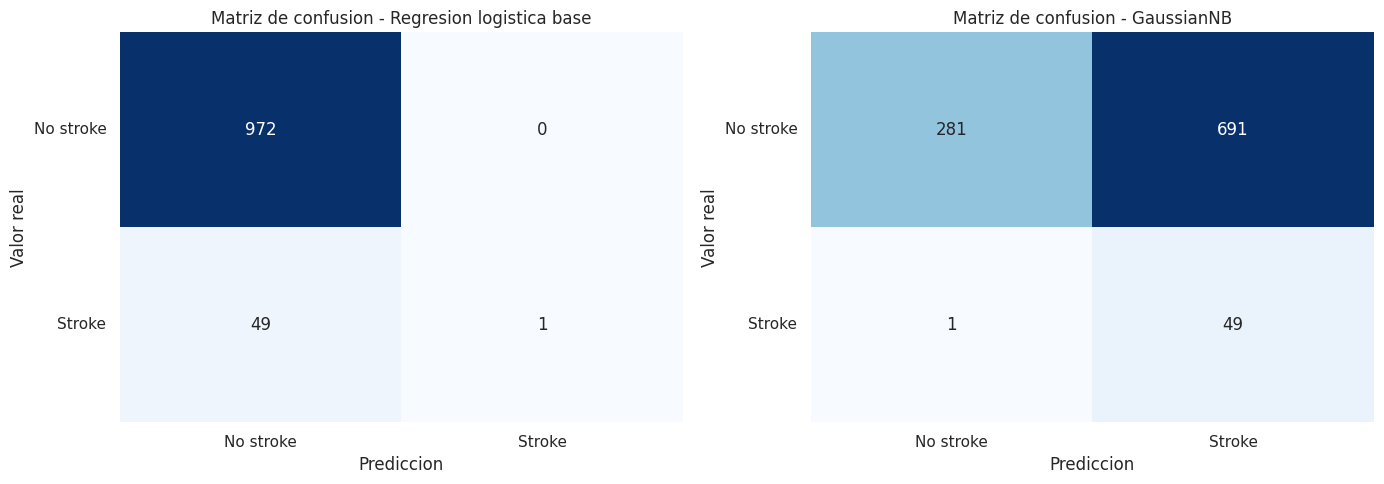

In [33]:
baseline_models = {
    "Regresion logistica base": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(continuous_features, categorical_features)),
            ("model", LogisticRegression(max_iter=2000)),
        ]
    ),
    "GaussianNB": Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(continuous_features, categorical_features)),
            ("model", GaussianNB()),
        ]
    ),
}

baseline_rows = []
baseline_reports = {}
baseline_predictions = {}
baseline_scores = {}
baseline_pipelines = {}

for model_name, pipeline in baseline_models.items():
    metrics_row, report, y_pred, y_score, fitted_pipeline = evaluate_classifier(
        model_name,
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    baseline_rows.append({
        "Modelo": model_name,
        "Accuracy": metrics_row["Accuracy"],
        "Precision": metrics_row["Precision"],
        "Recall": metrics_row["Recall"],
        "F1-score": metrics_row["F1-score"],
    })
    baseline_reports[model_name] = report
    baseline_predictions[model_name] = y_pred
    baseline_scores[model_name] = y_score
    baseline_pipelines[model_name] = fitted_pipeline

baseline_metrics_df = pd.DataFrame(baseline_rows).set_index("Modelo").sort_values("F1-score", ascending=False)
export_dataframe(baseline_metrics_df.round(6), RESULTS_DIR / "baseline_metrics.csv")

display(baseline_metrics_df.round(3))

for model_name, report in baseline_reports.items():
    print(f"\nReporte de clasificacion - {model_name}")
    display(report.round(3))

plot_confusion_matrices(y_test, baseline_predictions, n_cols=2)
save_current_figure(FIGURES_DIR / "cm_baseline_models.png")
plt.show()

## 10. Diagnostico de la regresion logistica base

La regresion logistica base obtuvo una `accuracy` alta, pero ese resultado puede ser enganoso cuando la clase positiva es minoritaria. En un problema clinico interesa detectar casos reales de stroke y no solo acertar la clase dominante.

In [34]:
logistic_base_scores = baseline_scores["Regresion logistica base"]
logistic_base_predictions = baseline_predictions["Regresion logistica base"]

logistic_base_diagnostic = compute_classification_metrics(
    y_test,
    logistic_base_predictions,
    logistic_base_scores,
)

logistic_base_diagnostic_df = pd.DataFrame(
    [logistic_base_diagnostic],
    index=["Regresion logistica base"],
)
export_dataframe(logistic_base_diagnostic_df.round(6), RESULTS_DIR / "logistic_base_diagnostic.csv")
display(logistic_base_diagnostic_df.round(3))

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,TP,TN,FP,FN,ROC-AUC,PR-AUC
Regresion logistica base,0.952,0.51,1.0,0.02,1.0,0.039,1,972,0,49,0.842,0.27


La matriz de confusion y las metricas detalladas muestran que el modelo base casi siempre predice la clase `0`. Por eso, la combinacion de `accuracy` alta y `recall` muy bajo invalida este enfoque como detector clinico y justifica el cambio de procedimiento.

## 11. Regresion logistica ajustada

El nuevo procedimiento modifica dos elementos del modelo: pondera las clases con `class_weight="balanced"` y ajusta el umbral de decision usando un conjunto de validacion derivado de `X_train`. El umbral se selecciona sobre validacion y luego se aplica a un modelo balanceado reentrenado sobre todo el conjunto de entrenamiento.

Umbral seleccionado: 0.55


,threshold,Precision,Recall,Specificity,F1-score,Balanced Accuracy,TP,TN,FP,FN
0,0.05,0.061,1.000,0.213,0.116,0.607,40,166,612,0
1,0.10,0.073,1.000,0.344,0.136,0.672,40,268,510,0
2,0.15,0.081,1.000,0.419,0.150,0.710,40,326,452,0
3,0.20,0.090,1.000,0.478,0.165,0.739,40,372,406,0
4,0.25,0.097,0.975,0.535,0.177,0.755,39,416,362,1
5,0.30,0.106,0.950,0.589,0.191,0.769,38,458,320,2
6,0.35,0.120,0.950,0.641,0.213,0.796,38,499,279,2
7,0.40,0.124,0.900,0.672,0.218,0.786,36,523,255,4
8,0.45,0.129,0.850,0.706,0.224,0.778,34,549,229,6
9,0.50,0.143,0.825,0.747,0.244,0.786,33,581,197,7


,threshold,Precision,Recall,Specificity,F1-score,Balanced Accuracy,TP,TN,FP,FN
10,0.55,0.15,0.8,0.766,0.252,0.783,32,596,182,8


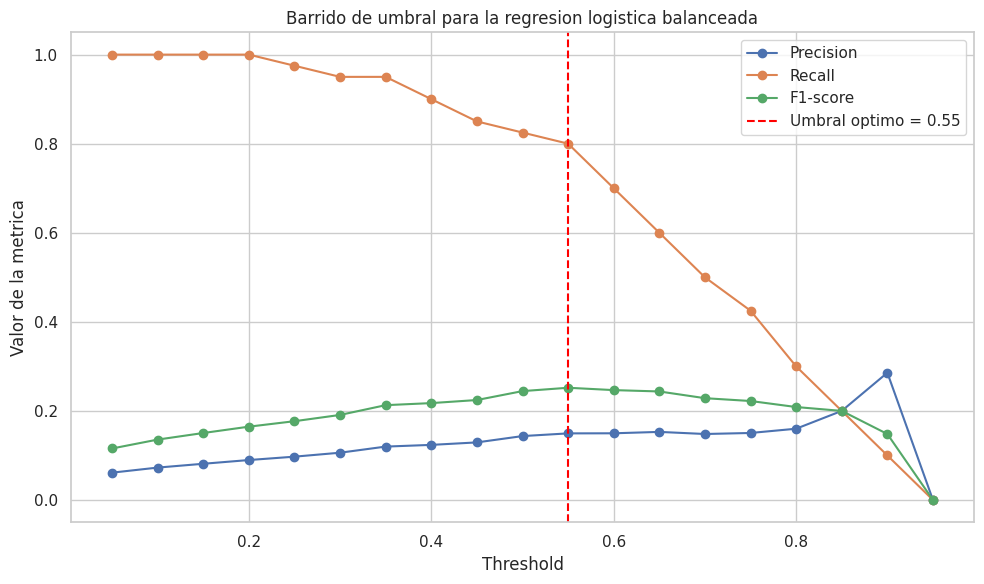

In [35]:
X_subtrain, X_val, y_subtrain, y_val = split_training_for_threshold_tuning(X_train, y_train)

balanced_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(continuous_features, categorical_features)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)
balanced_tuning_pipeline.fit(X_subtrain, y_subtrain)

validation_scores = extract_positive_scores(balanced_tuning_pipeline, X_val)
threshold_grid = np.arange(0.05, 1.00, 0.05)
threshold_results_df = evaluate_thresholds(y_val, validation_scores, threshold_grid)
selected_threshold = select_best_threshold(threshold_results_df)

balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(continuous_features, categorical_features)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ]
)
balanced_logistic_pipeline.fit(X_train, y_train)

balanced_test_scores = extract_positive_scores(balanced_logistic_pipeline, X_test)
balanced_predictions_050 = apply_threshold(balanced_test_scores, 0.50)
balanced_predictions_opt = apply_threshold(balanced_test_scores, selected_threshold)

export_dataframe(threshold_results_df.round(6), RESULTS_DIR / "threshold_validation_metrics.csv")

print(f"Umbral seleccionado: {selected_threshold:.2f}")
display(threshold_results_df.round(3))
display(threshold_results_df.loc[threshold_results_df["threshold"] == selected_threshold].round(3))

plot_threshold_tradeoff(threshold_results_df, selected_threshold)
save_current_figure(FIGURES_DIR / "threshold_tradeoff_balanced_logistic.png")
plt.show()

## 12. Comparacion final de modelos

La comparacion final conserva el modelo original, introduce la version balanceada con umbral por defecto y agrega la version balanceada con umbral ajustado para justificar el cambio metodologico con evidencia.

,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,TP,TN,FP,FN,ROC-AUC,PR-AUC
Modelo,,,,,,,,,,,,
Regresion logistica balanceada (threshold optimo),0.779,0.789,0.156,0.80,0.778,0.261,40,756,216,10,0.844,0.268
Regresion logistica balanceada (threshold=0.50),0.747,0.772,0.138,0.80,0.744,0.236,40,723,249,10,0.844,0.268
GaussianNB,0.323,0.635,0.066,0.98,0.289,0.124,49,281,691,1,0.787,0.155
Regresion logistica base,0.952,0.510,1.000,0.02,1.000,0.039,1,972,0,49,0.842,0.270


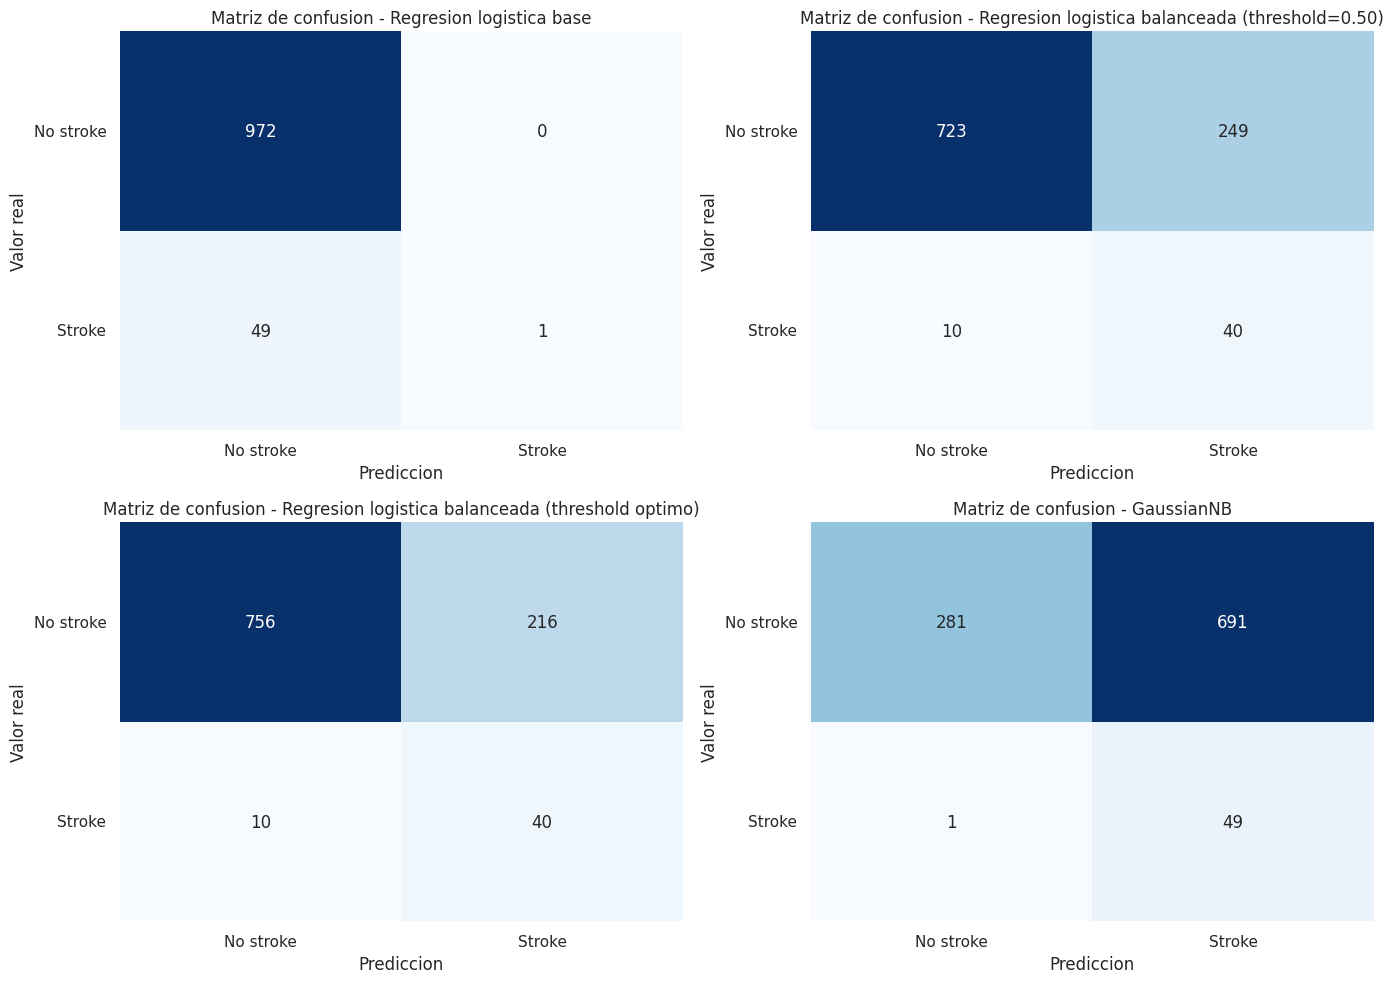

In [36]:
final_predictions = {
    "Regresion logistica base": logistic_base_predictions,
    "Regresion logistica balanceada (threshold=0.50)": balanced_predictions_050,
    "Regresion logistica balanceada (threshold optimo)": balanced_predictions_opt,
    "GaussianNB": baseline_predictions["GaussianNB"],
}

final_scores = {
    "Regresion logistica base": logistic_base_scores,
    "Regresion logistica balanceada (threshold=0.50)": balanced_test_scores,
    "Regresion logistica balanceada (threshold optimo)": balanced_test_scores,
    "GaussianNB": baseline_scores["GaussianNB"],
}

final_rows = []
for model_name in final_predictions:
    metrics_row = compute_classification_metrics(
        y_test,
        final_predictions[model_name],
        final_scores[model_name],
    )
    metrics_row["Modelo"] = model_name
    final_rows.append(metrics_row)

final_comparison_df = (
    pd.DataFrame(final_rows)
    .set_index("Modelo")
    .sort_values(by=["F1-score", "Recall"], ascending=[False, False])
)

export_dataframe(final_comparison_df.round(6), RESULTS_DIR / "final_model_comparison.csv")
display(final_comparison_df.round(3))

plot_confusion_matrices(y_test, final_predictions, n_cols=2)
save_current_figure(FIGURES_DIR / "cm_final_models.png")
plt.show()

## 13. Conclusiones finales

In [37]:
best_f1 = final_comparison_df["F1-score"].idxmax()
best_recall = final_comparison_df["Recall"].idxmax()
best_balanced_accuracy = final_comparison_df["Balanced Accuracy"].idxmax()

print(f"Mejor modelo por F1-score: {best_f1}")
print(f"Mejor modelo por Recall: {best_recall}")
print(f"Mejor modelo por Balanced Accuracy: {best_balanced_accuracy}")
print(f"Umbral seleccionado para la regresion logistica ajustada: {selected_threshold:.2f}")
print("La conclusion formal y la discusion completa se integraran en el articulo IEEE.")

Mejor modelo por F1-score: Regresion logistica balanceada (threshold optimo)
Mejor modelo por Recall: GaussianNB
Mejor modelo por Balanced Accuracy: Regresion logistica balanceada (threshold optimo)
Umbral seleccionado para la regresion logistica ajustada: 0.55
La conclusion formal y la discusion completa se integraran en el articulo IEEE.


# Compartiva Final
- Los resultados finales evidencian que el **principal problema** del modelo inicial no estaba en su **exactitud global**, sino en su **incapacidad para detectar la clase minoritaria**. La **regresión logística base** obtuvo una exactitud cercana a `0.952`, pero este valor fue engañoso debido al fuerte desbalance del conjunto de datos. La matriz de confusión mostró `972` verdaderos negativos, `0` falsos positivos, `49` falsos negativos y apenas `1` verdadero positivo, lo que equivale a un **recall** de aproximadamente `0.02`. En términos prácticos, el modelo casi siempre predijo la clase **`No stroke`**, por lo que **no resulta adecuado para un contexto clínico** donde es prioritario reducir los falsos negativos.

- La **regresión logística balanceada** con un umbral de `0.50` corrigió de forma importante este comportamiento. En este caso, el modelo logró identificar `40` de `50` casos reales de stroke, reduciendo los falsos negativos a `10`. Esto elevó el **recall** hasta `0.80`, lo que representa una mejora sustancial frente al modelo base. Sin embargo, esta ganancia se obtuvo a costa de `249` falsos positivos, lo que redujo la exactitud a aproximadamente `0.747`. Aun así, desde una **perspectiva clínica**, este modelo resulta **mucho más útil** que la versión inicial porque logra detectar una mayor proporción de pacientes en riesgo.

- La **regresión logística balanceada** con **umbral óptimo** fue la variante más equilibrada. Conservó los `40` verdaderos positivos y los `10` falsos negativos observados con el umbral `0.50`, pero redujo los falsos positivos de `249` a `216` y aumentó los verdaderos negativos de `723` a `756`. Esto mejoró simultáneamente la **exactitud**, la **especificidad**, la **precisión** y el **F1-score**, sin sacrificar **recall**. En consecuencia, esta versión representa el **mejor compromiso** entre sensibilidad y control de falsas alarmas dentro de los modelos evaluados.
- Por su parte, **`GaussianNB`** fue el modelo con **mayor sensibilidad**, al detectar `49` de `50` casos reales de stroke, con un **recall** de `0.98`. No obstante, produjo `691` falsos positivos, lo que redujo drásticamente su exactitud a aproximadamente `0.323` y su precisión a cerca de `0.066`. Esto indica que, aunque es muy agresivo para detectar la clase positiva, genera **demasiadas alertas incorrectas** como para considerarlo la mejor alternativa en esta actividad.

- En conjunto, los resultados muestran que la **mejor opción** no es el modelo con mayor **`accuracy`** ni el de mayor **`recall`** por separado, sino el que ofrece el **equilibrio más razonable** entre detección de casos positivos y reducción de errores de clasificación. Bajo este criterio, la **regresión logística balanceada con umbral óptimo** fue el modelo más defendible, ya que mantuvo una **sensibilidad alta** y mejoró el **control de falsos positivos** respecto a las demás alternativas.